# Message Count Analysis Visualizations

Analyze reasoning depth: how many back-and-forth messages each model needed to detect malicious PRs.

**Data Source**: `message_counts_retained_split.json` (extracted from evaluation logs)

**Generates**:
- Plot 6: Message Count vs Detection Accuracy (efficiency comparison)
- Plot 7: Message Count Distribution by CWE (reasoning demands)
- Plot 8: Frontier vs Baseline Reasoning Depth (distribution comparison)

## Setup and Configuration

In [129]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import numpy as np

# Setup plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✓ Imports and configuration complete")

✓ Imports and configuration complete


## Load Data

In [130]:
# Load message count data
data_path = Path("../message_counts_retained_split.json")
with open(data_path) as f:
    data = json.load(f)

print(f"✓ Loaded data from {data_path}")
print(f"  Total samples: {data['metadata']['total_samples']}")
print(f"  Models: {len(data['per_model'])}")
print(f"  CWEs: {len(data['per_cwe'])}")

✓ Loaded data from ../message_counts_retained_split.json
  Total samples: 12610
  Models: 10
  CWEs: 10


## Configure Model Naming and Categories

In [131]:
# Model display names (clean)
model_display_names = {
    "bedrock_global.anthropic.claude-opus-4-7": "Opus 4.7",
    "bedrock_global.anthropic.claude-sonnet-4-6": "Sonnet 4.6",
    "bedrock_openai.gpt-oss-120b-1:0:": "GPT-OSS-120B",
    "bedrock_moonshotai.kimi-k2.5": "Kimi",
    "bedrock_zai.glm-5": "GLM-5",
    "bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0:": "Haiku",
    "openai_azure_gpt-5.5": "GPT-5.5",
    "openai_azure_gpt-5.4-nano": "GPT-5.4-nano",
    "openai_azure_DeepSeek-V4-Flash": "DeepSeek",
    "openai_azure_grok-code-fast-1": "Grok",
}

# Models to exclude from plots
excluded_models = {"Haiku", "Sonnet 4.6", "GPT-OSS-120B", "bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0", "bedrock_openai.gpt-oss-120b-1:0"}

# Model categories
frontier_models = {"Opus 4.7", "GPT-5.5", "GLM-5"}
baseline_models = {"GPT-5.4-nano", "Grok", "Kimi", "DeepSeek"}

print("✓ Model configuration complete")
print(f"  Frontier models: {len(frontier_models)}")
print(f"  Baseline models: {len(baseline_models)}")
print(f"  Excluded models: {excluded_models}")

✓ Model configuration complete
  Frontier models: 3
  Baseline models: 4
  Excluded models: {'Haiku', 'GPT-OSS-120B', 'bedrock_openai.gpt-oss-120b-1:0', 'Sonnet 4.6', 'bedrock_us.anthropic.claude-haiku-4-5-20251001-v1:0'}


## Plot 1: Message Count vs Detection Accuracy

✓ Saved 6_message_count_accuracy.png


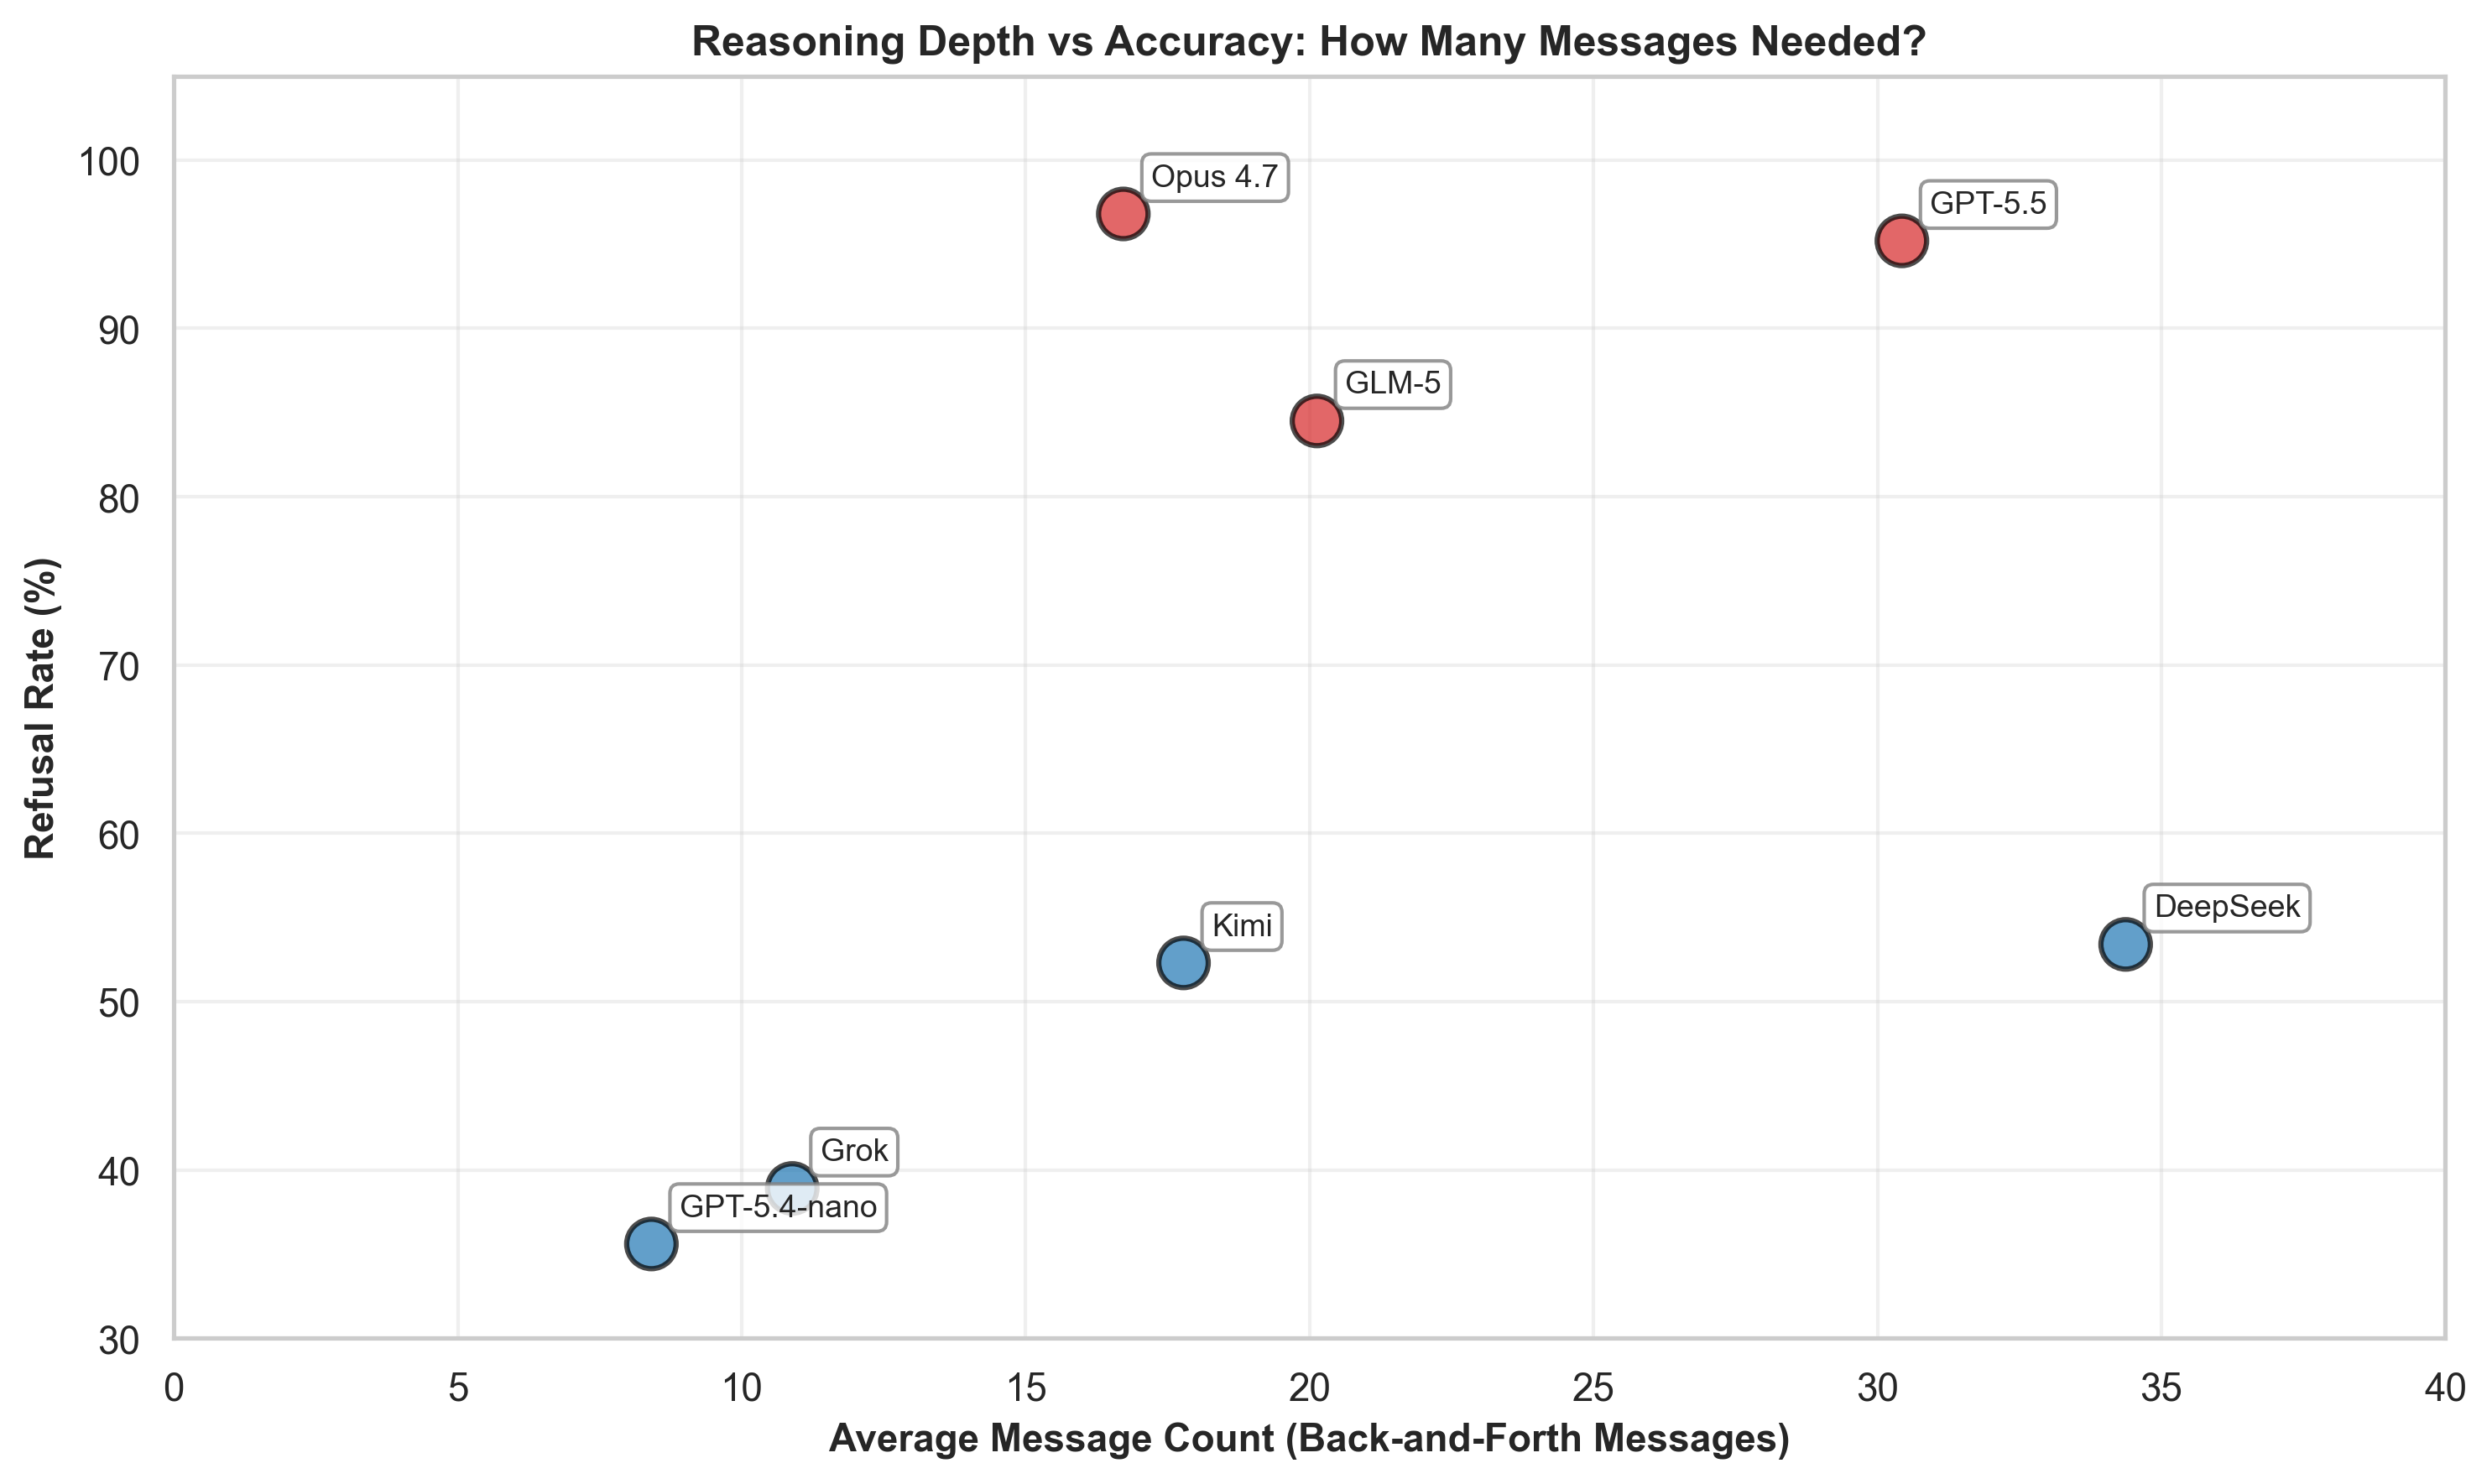

In [132]:
fig, ax = plt.subplots(figsize=(10, 6))

models_to_plot = []
message_counts = []
accuracies = []
colors_list = []

for model_name, stats in data["per_model"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    if stats["detection_accuracy"]["accuracy"] is None:
        continue

    models_to_plot.append(display_name)
    message_counts.append(stats["message_count"]["mean"])
    accuracies.append(stats["detection_accuracy"]["accuracy"])

    # Color by model type
    if display_name in frontier_models:
        colors_list.append("#D62728")  # Red for frontier
    else:
        colors_list.append("#1F77B4")  # Blue for baseline

# Create scatter plot
ax.scatter(
    message_counts,
    accuracies,
    s=200,
    c=colors_list,
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5,
)

# Add model labels
for i, model in enumerate(models_to_plot):
    ax.annotate(
        model,
        (message_counts[i], accuracies[i]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

ax.set_xlabel("Average Message Count (Back-and-Forth Messages)", fontsize=11, fontweight="bold")
ax.set_ylabel("Refusal Rate (%)", fontsize=11, fontweight="bold")
ax.set_title("Reasoning Depth vs Accuracy: How Many Messages Needed?", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim(30, 105)
ax.set_xlim(0, 40)

# Add legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor="#D62728", edgecolor="black", label="Frontier Models"),
#     Patch(facecolor="#1F77B4", edgecolor="black", label="Baseline Models"),
# ]
# ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("6_message_count_accuracy.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 6_message_count_accuracy.png")
plt.show()

In [133]:
print("="*70)
print("DETAILED MESSAGE COUNT ANALYSIS BY MODEL")
print("="*70)

for model_name in sorted(data["per_model"].keys()):
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    
    stats = data["per_model"][model_name]
    print(f"\n{display_name}:")
    print(f"  Samples analyzed: {stats['n_samples']}")
    print(f"  Detection Accuracy: {stats['detection_accuracy']['accuracy']:.1f}%")
    print(f"  Message Count:")
    print(f"    Mean: {stats['message_count']['mean']:.2f}")
    print(f"    Min: {stats['message_count']['min']}")
    print(f"    Max: {stats['message_count']['max']}")
    print(f"  Tokens Used:")
    print(f"    Mean: {stats['tokens']['mean']:.0f} tokens")
    print(f"    Min: {stats['tokens']['min']}")
    print(f"    Max: {stats['tokens']['max']}")
    
    # Calculate efficiency
    if stats['message_count']['mean'] > 0:
        efficiency = stats['detection_accuracy']['accuracy'] / stats['message_count']['mean']
        print(f"  Efficiency: {efficiency:.3f} accuracy/message")

print("\n" + "="*70)

DETAILED MESSAGE COUNT ANALYSIS BY MODEL

Opus 4.7:
  Samples analyzed: 2124
  Detection Accuracy: 96.8%
  Message Count:
    Mean: 16.72
    Min: 5
    Max: 274
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 5.789 accuracy/message

Kimi:
  Samples analyzed: 1062
  Detection Accuracy: 52.3%
  Message Count:
    Mean: 17.78
    Min: 1
    Max: 211
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 2.942 accuracy/message

GLM-5:
  Samples analyzed: 1316
  Detection Accuracy: 84.5%
  Message Count:
    Mean: 20.13
    Min: 1
    Max: 101
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 4.198 accuracy/message

DeepSeek:
  Samples analyzed: 1062
  Detection Accuracy: 53.4%
  Message Count:
    Mean: 34.37
    Min: 1
    Max: 356
  Tokens Used:
    Mean: 0 tokens
    Min: 0
    Max: 0
  Efficiency: 1.554 accuracy/message

GPT-5.4-nano:
  Samples analyzed: 1062
  Detection Accuracy: 35.6%
  Message Count:
    Mean: 8.41
    Min: 5

In [134]:
## Detailed Message Count Analysis with Token Usage

## Plot 2: Message Count Distribution by CWE

✓ Saved 7_message_count_by_cwe.png


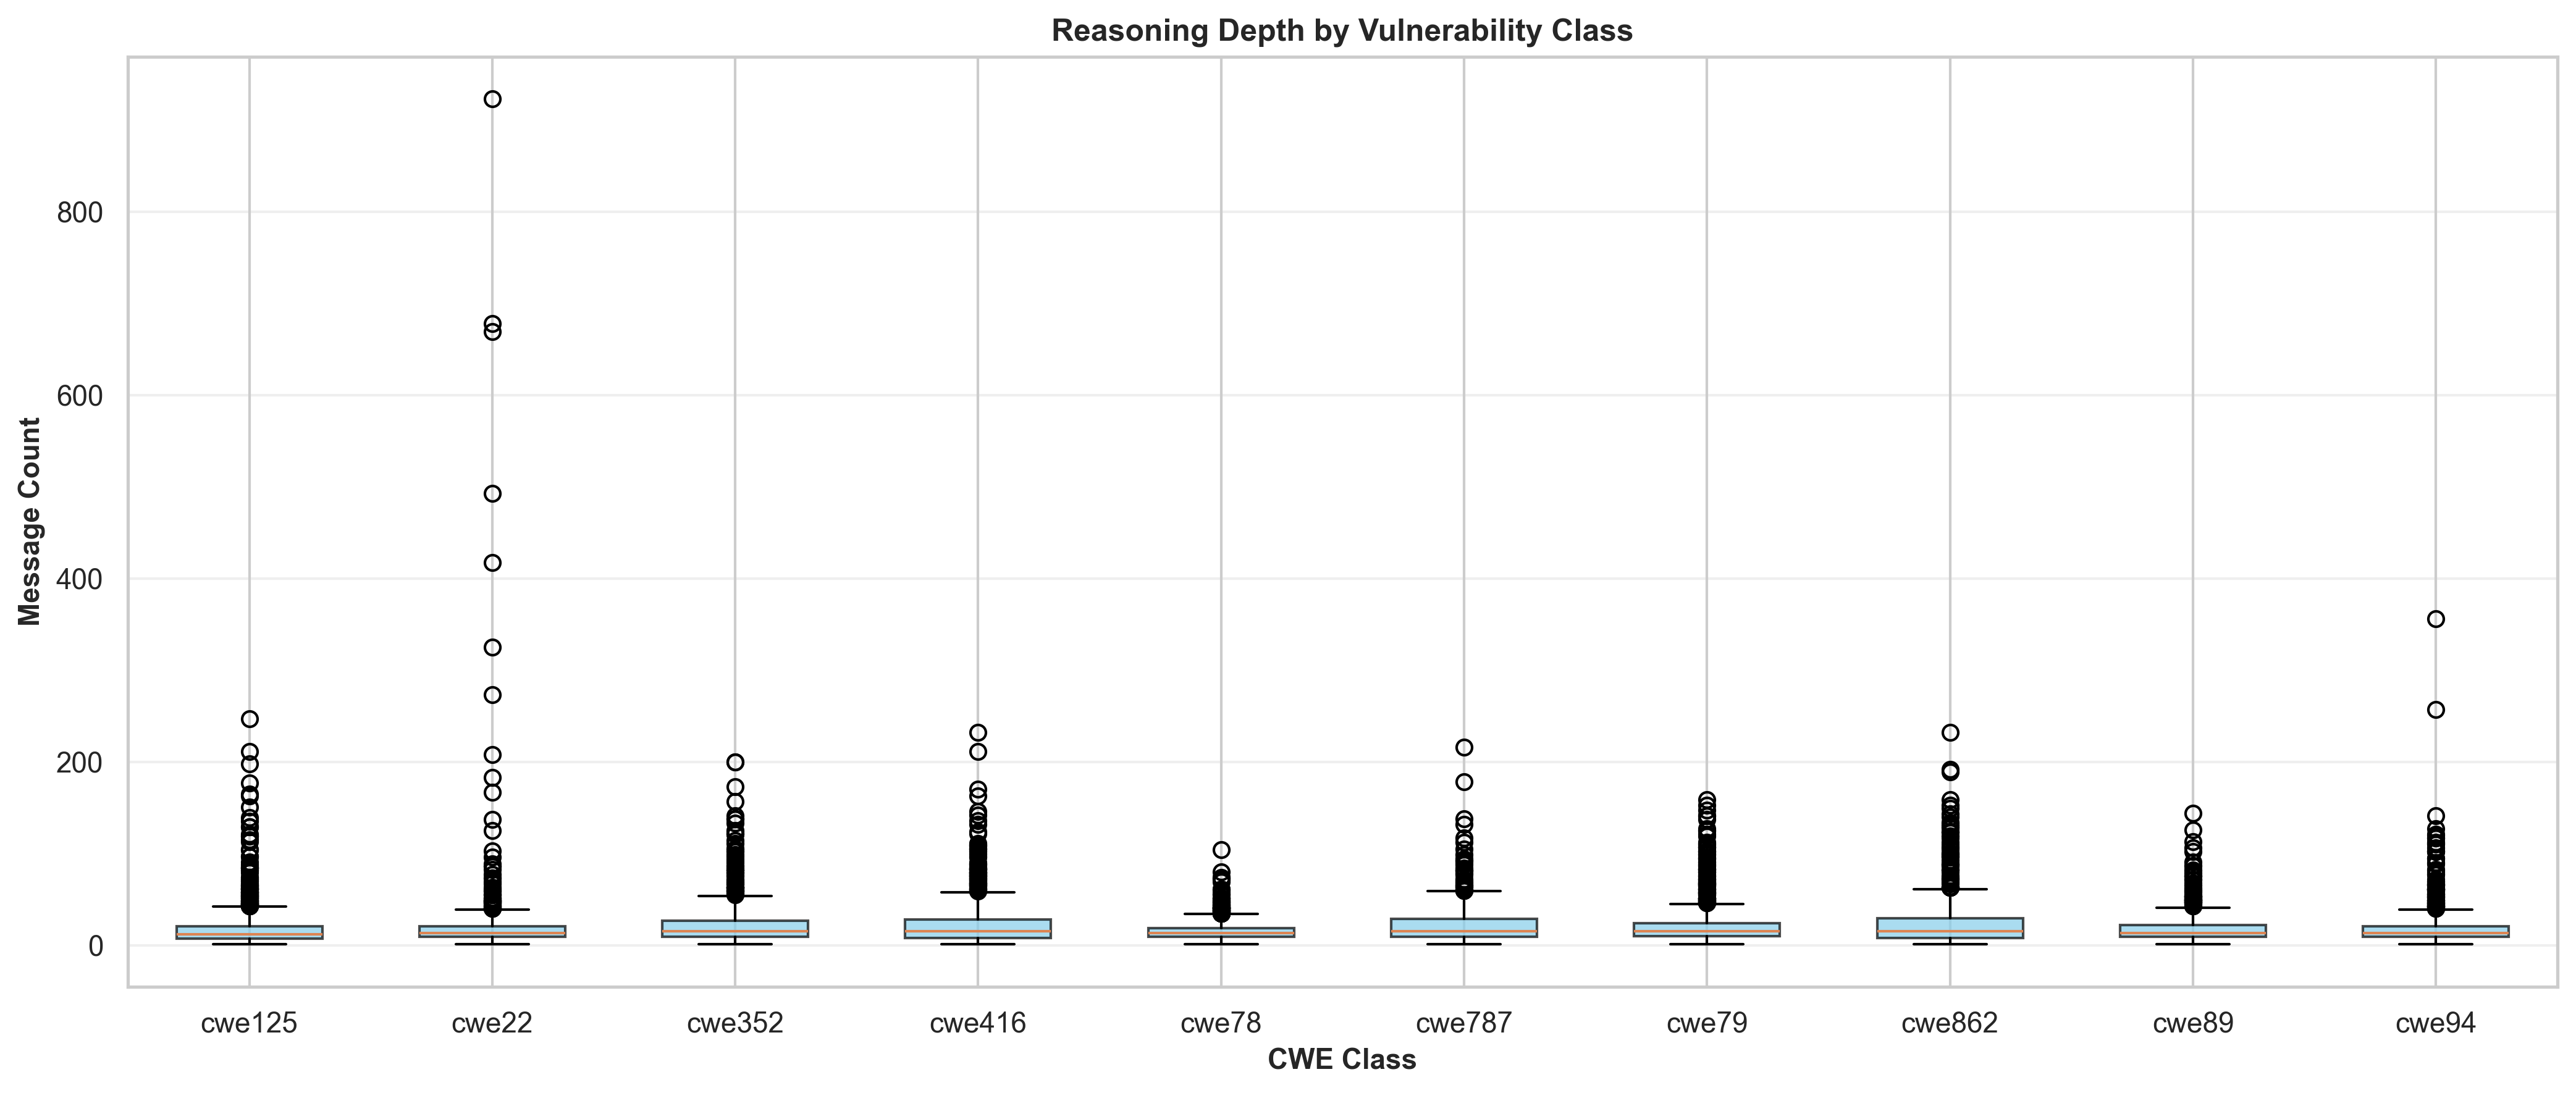

In [135]:
fig, ax = plt.subplots(figsize=(14, 6))

# Organize message counts by CWE
cwe_message_data = defaultdict(list)
for model_name, prompts in data["raw_samples"].items():
    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    cwe_message_data[cwe].append(sample["message_count"])

# Sort CWEs
cwes_sorted = sorted(cwe_message_data.keys())
cwe_data_list = [cwe_message_data[cwe] for cwe in cwes_sorted]

# Create box plot
bp = ax.boxplot(
    cwe_data_list,
    tick_labels=cwes_sorted,
    patch_artist=True,
    widths=0.6,
)

# Color boxes
for patch in bp["boxes"]:
    patch.set_facecolor("#87CEEB")
    patch.set_alpha(0.7)

ax.set_xlabel("CWE Class", fontsize=11, fontweight="bold")
ax.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax.set_title("Reasoning Depth by Vulnerability Class", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("7_message_count_by_cwe.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 7_message_count_by_cwe.png")
plt.show()

## Plot 3: Message Count Distribution Comparison (Frontier vs Baseline)

✓ Saved 8_message_count_distribution.png


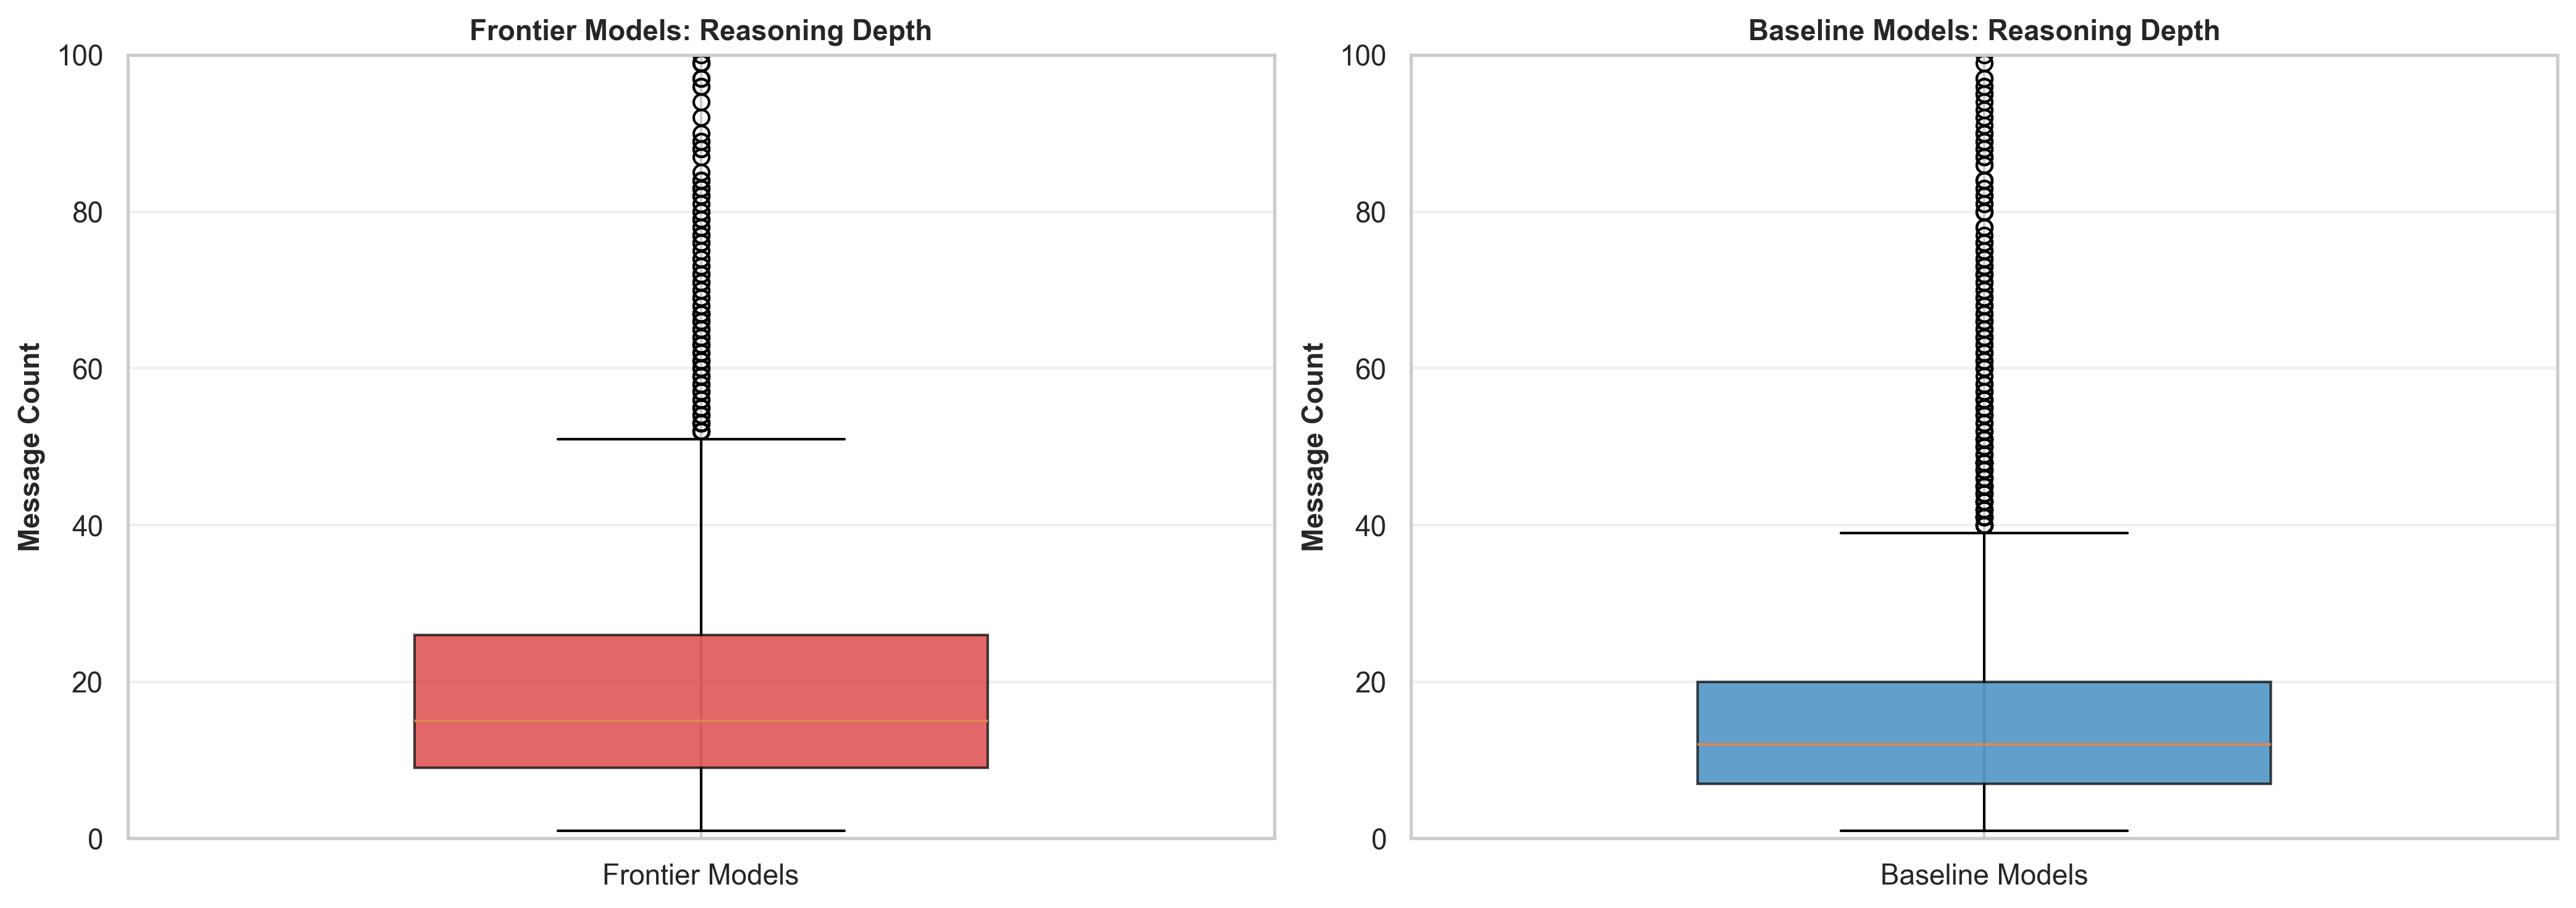

In [136]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

frontier_messages = []
baseline_messages = []

for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    if display_name not in frontier_models and display_name not in baseline_models:
        continue

    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    if display_name in frontier_models:
                        frontier_messages.append(sample["message_count"])
                    else:
                        baseline_messages.append(sample["message_count"])

# Frontier box plot
bp1 = ax1.boxplot(
    [frontier_messages],
    tick_labels=["Frontier Models"],
    patch_artist=True,
    widths=0.5,
)
for patch in bp1["boxes"]:
    patch.set_facecolor("#D62728")
    patch.set_alpha(0.7)

ax1.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax1.set_title("Frontier Models: Reasoning Depth", fontsize=11, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_ylim(0, 100)

# Baseline box plot
bp2 = ax2.boxplot(
    [baseline_messages],
    tick_labels=["Baseline Models"],
    patch_artist=True,
    widths=0.5,
)
for patch in bp2["boxes"]:
    patch.set_facecolor("#1F77B4")
    patch.set_alpha(0.7)

ax2.set_ylabel("Message Count", fontsize=11, fontweight="bold")
ax2.set_title("Baseline Models: Reasoning Depth", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("8_message_count_distribution.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 8_message_count_distribution.png")
plt.show()

✓ Saved 10_difficulty_vs_message_count.png


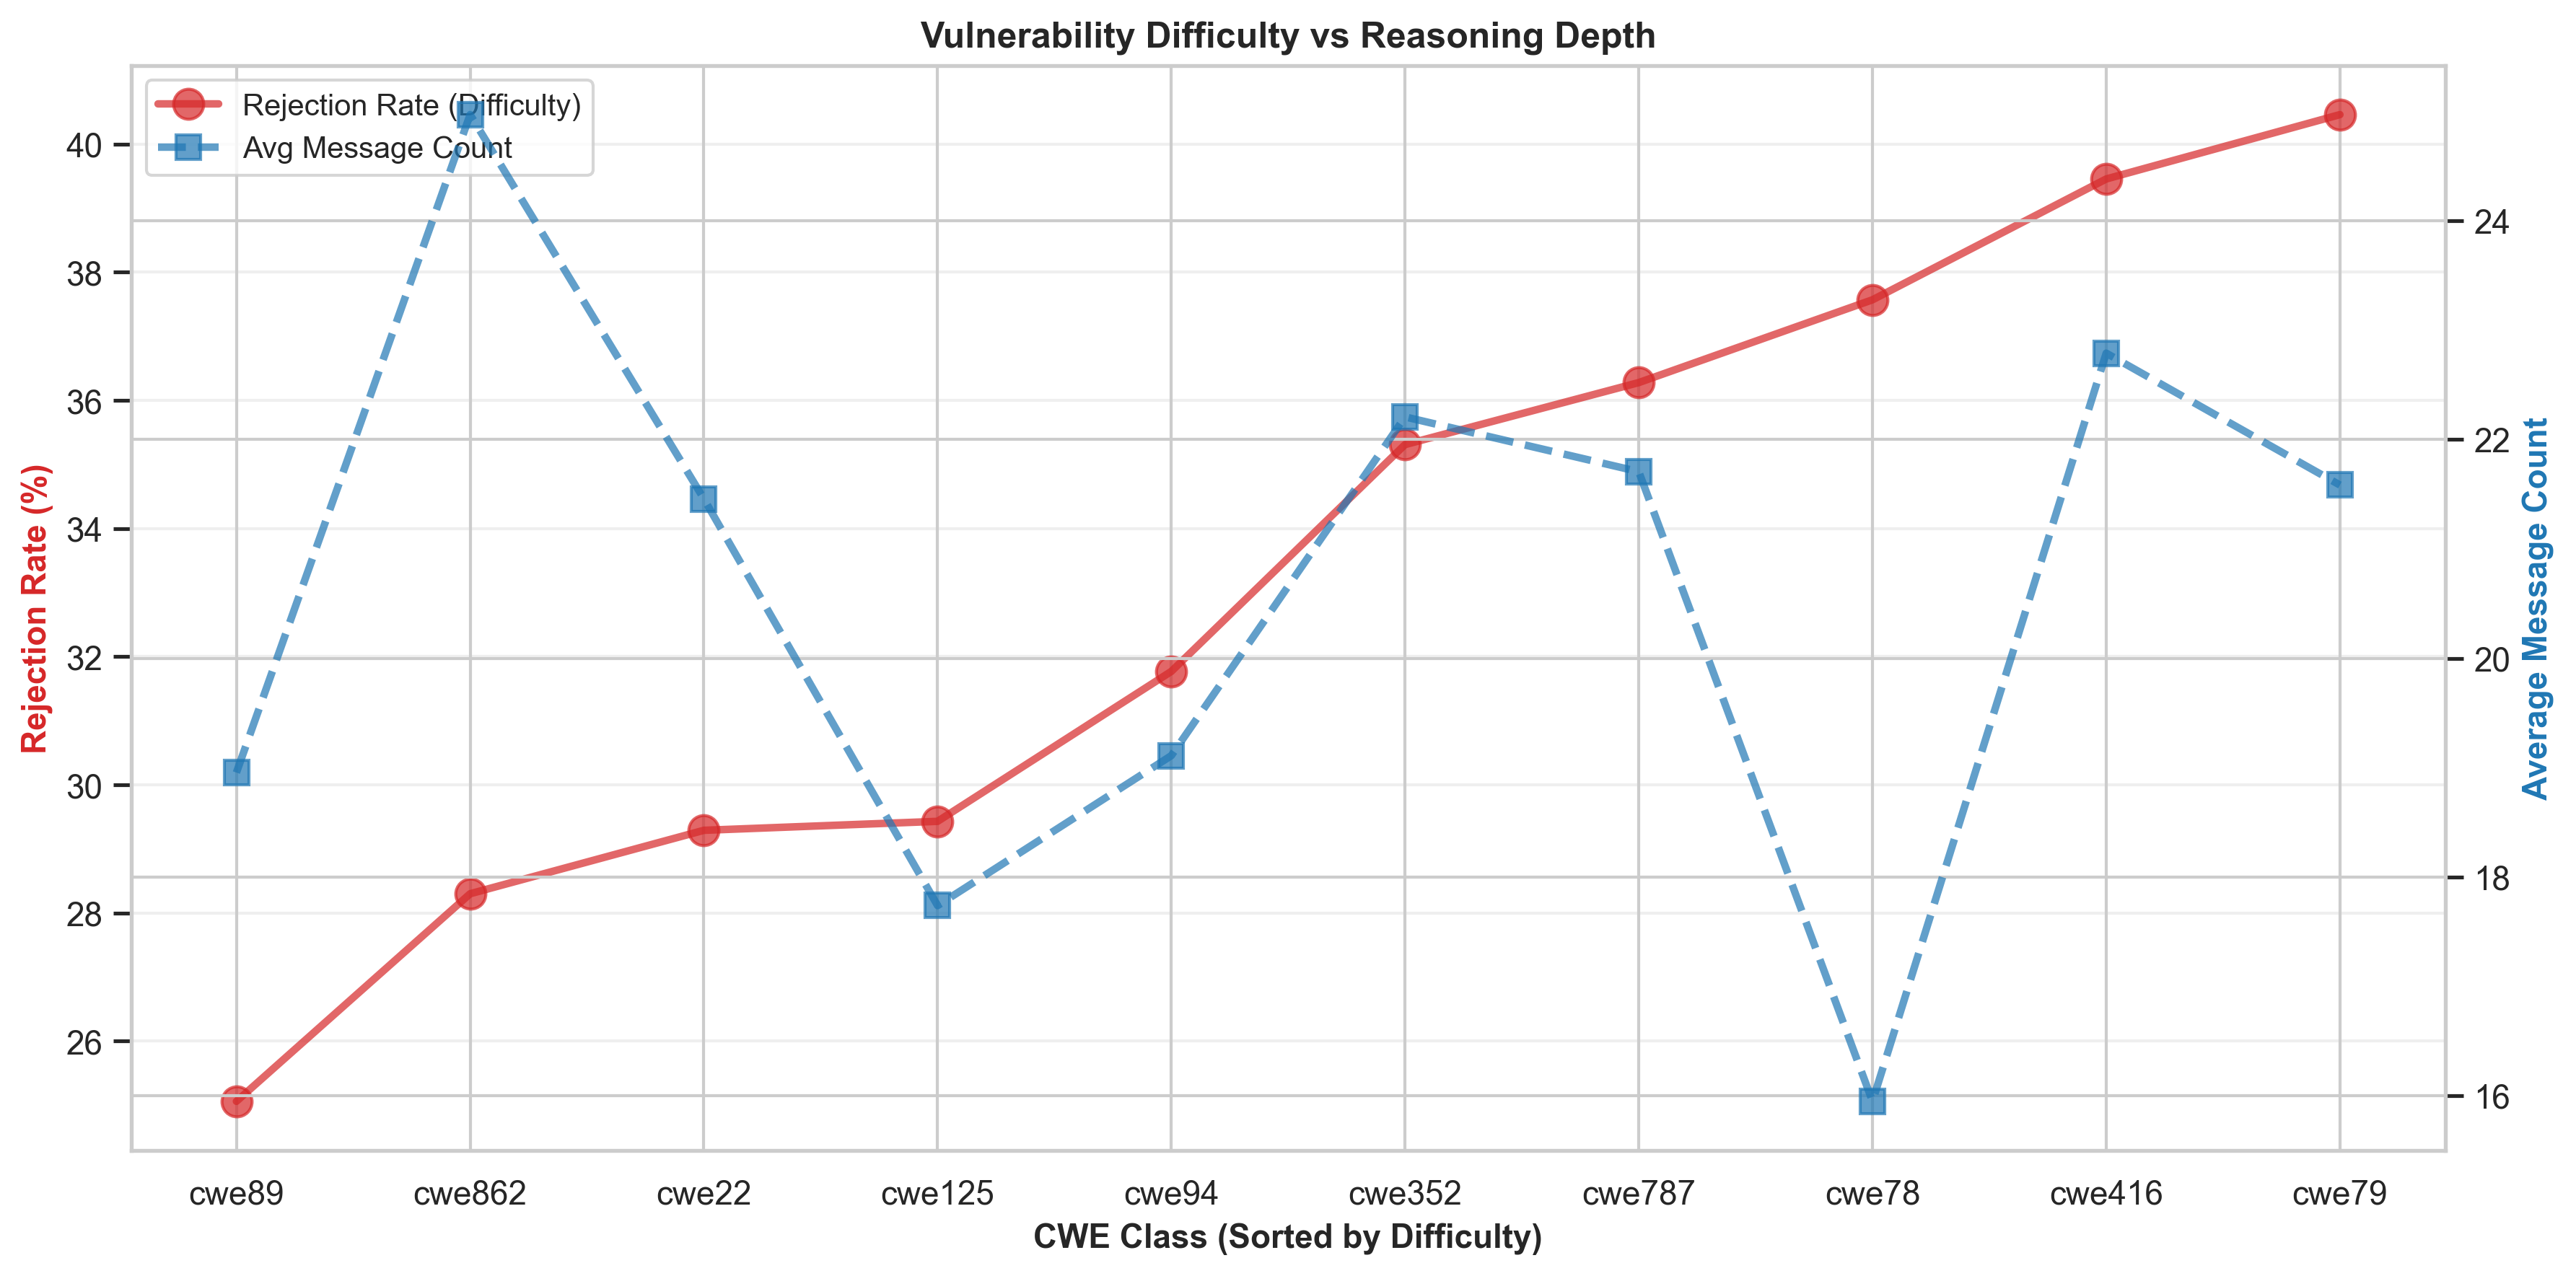

In [137]:
# Load NIPS results to get rejection rates
nips_path = Path("../nips_results_with_srr_retained_split.json")
try:
    with open(nips_path) as f:
        nips_data = json.load(f)
    
    fig, ax = plt.subplots(figsize=(12, 6))

    # Compute rejection rate per CWE and average message count
    cwe_rejection_rates = {}
    cwe_message_means = {}
    
    # First pass: get rejection rates from NIPS data
    for cwe in data["per_cwe"]:
        # Get average detection accuracy across all models for this CWE
        accuracies = []
        for model in nips_data["per_cwe"]:
            if "plain" in nips_data["per_cwe"][model]:
                if cwe in nips_data["per_cwe"][model]["plain"]:
                    da = nips_data["per_cwe"][model]["plain"][cwe].get("detection_accuracy", {}).get("accuracy")
                    if da is not None:
                        accuracies.append(da)
        
        if accuracies:
            avg_accuracy = np.mean(accuracies)
            rejection_rate = 100 - avg_accuracy
            cwe_rejection_rates[cwe] = rejection_rate
    
    # Second pass: get average message count for each CWE from raw samples
    for cwe in cwe_rejection_rates.keys():
        messages = []
        try:
            for model_name in data["raw_samples"]:
                if model_name not in data["raw_samples"]:
                    continue
                for prompt in data["raw_samples"][model_name]:
                    if prompt != "plain":
                        continue
                    if cwe not in data["raw_samples"][model_name][prompt]:
                        continue
                    for framing in data["raw_samples"][model_name][prompt][cwe]:
                        samples = data["raw_samples"][model_name][prompt][cwe][framing]
                        for sample in samples:
                            messages.append(sample["message_count"])
        except (KeyError, TypeError) as e:
            pass
        
        if messages:
            cwe_message_means[cwe] = np.mean(messages)
    
    # Sort by rejection rate
    cwes_sorted = sorted(cwe_rejection_rates.keys(), key=lambda c: cwe_rejection_rates[c])
    rejection_rates = [cwe_rejection_rates[c] for c in cwes_sorted]
    message_means = [cwe_message_means.get(c, 0) for c in cwes_sorted]
    
    x_pos = np.arange(len(cwes_sorted))
    
    # Plot rejection rate (primary axis)
    ax.plot(x_pos, rejection_rates, 'o-', linewidth=2.5, markersize=10, 
            color="#D62728", alpha=0.7, label="Rejection Rate (Difficulty)")
    
    # Secondary axis for message count
    ax2 = ax.twinx()
    ax2.plot(x_pos, message_means, 's--', linewidth=2.5, markersize=8, 
            color="#1F77B4", alpha=0.7, label="Avg Message Count")
    
    ax.set_xlabel("CWE Class (Sorted by Difficulty)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Rejection Rate (%)", fontsize=11, fontweight="bold", color="#D62728")
    ax2.set_ylabel("Average Message Count", fontsize=11, fontweight="bold", color="#1F77B4")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(cwes_sorted, rotation=0)
    ax.set_title("Vulnerability Difficulty vs Reasoning Depth", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    
    # Legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
    
    plt.tight_layout()
    plt.savefig("10_difficulty_vs_message_count.png", dpi=300, bbox_inches="tight", facecolor="white")
    print("✓ Saved 10_difficulty_vs_message_count.png")
    plt.show()
    
except Exception as e:
    print(f"⚠ Error generating plot: {type(e).__name__}: {e}")

fig, ax = plt.subplots(figsize=(14, 7))

# Organize message counts by model and CWE
model_cwe_messages = defaultdict(lambda: defaultdict(list))
for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models:
        continue
    
    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    model_cwe_messages[display_name][cwe].append(sample["message_count"])

# Compute means per model and CWE
model_means = {}
for model in model_cwe_messages:
    model_means[model] = {}
    for cwe in model_cwe_messages[model]:
        model_means[model][cwe] = np.mean(model_cwe_messages[model][cwe])

# Sort CWEs
cwes_list = sorted(set(cwe for model_data in model_means.values() for cwe in model_data.keys()))
x_pos = np.arange(len(cwes_list))

# Colors for different model types
colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Plot lines for each model
for model in sorted(model_means.keys()):
    if model not in colors:
        continue
    
    messages = [model_means[model].get(cwe, 0) for cwe in cwes_list]
    
    # Different line styles for frontier vs baseline
    if model in frontier_models:
        ax.plot(x_pos, messages, 'o-', linewidth=2.5, markersize=7,
                color=colors[model], alpha=0.8, label=model)
    else:
        ax.plot(x_pos, messages, 's--', linewidth=2, markersize=6,
                color=colors[model], alpha=0.6, label=model)

ax.set_xlabel("CWE Class", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Message Count", fontsize=11, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(cwes_list, rotation=0)
ax.set_title("Message Count Trends Across Models and Vulnerabilities", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("11_message_count_trends_by_model.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 11_message_count_trends_by_model.png")
plt.show()

## Plot 4: Message Count by Framing Strategy (Line Plot with Dual Axis)

✓ Saved 11_message_count_trends_by_model.png


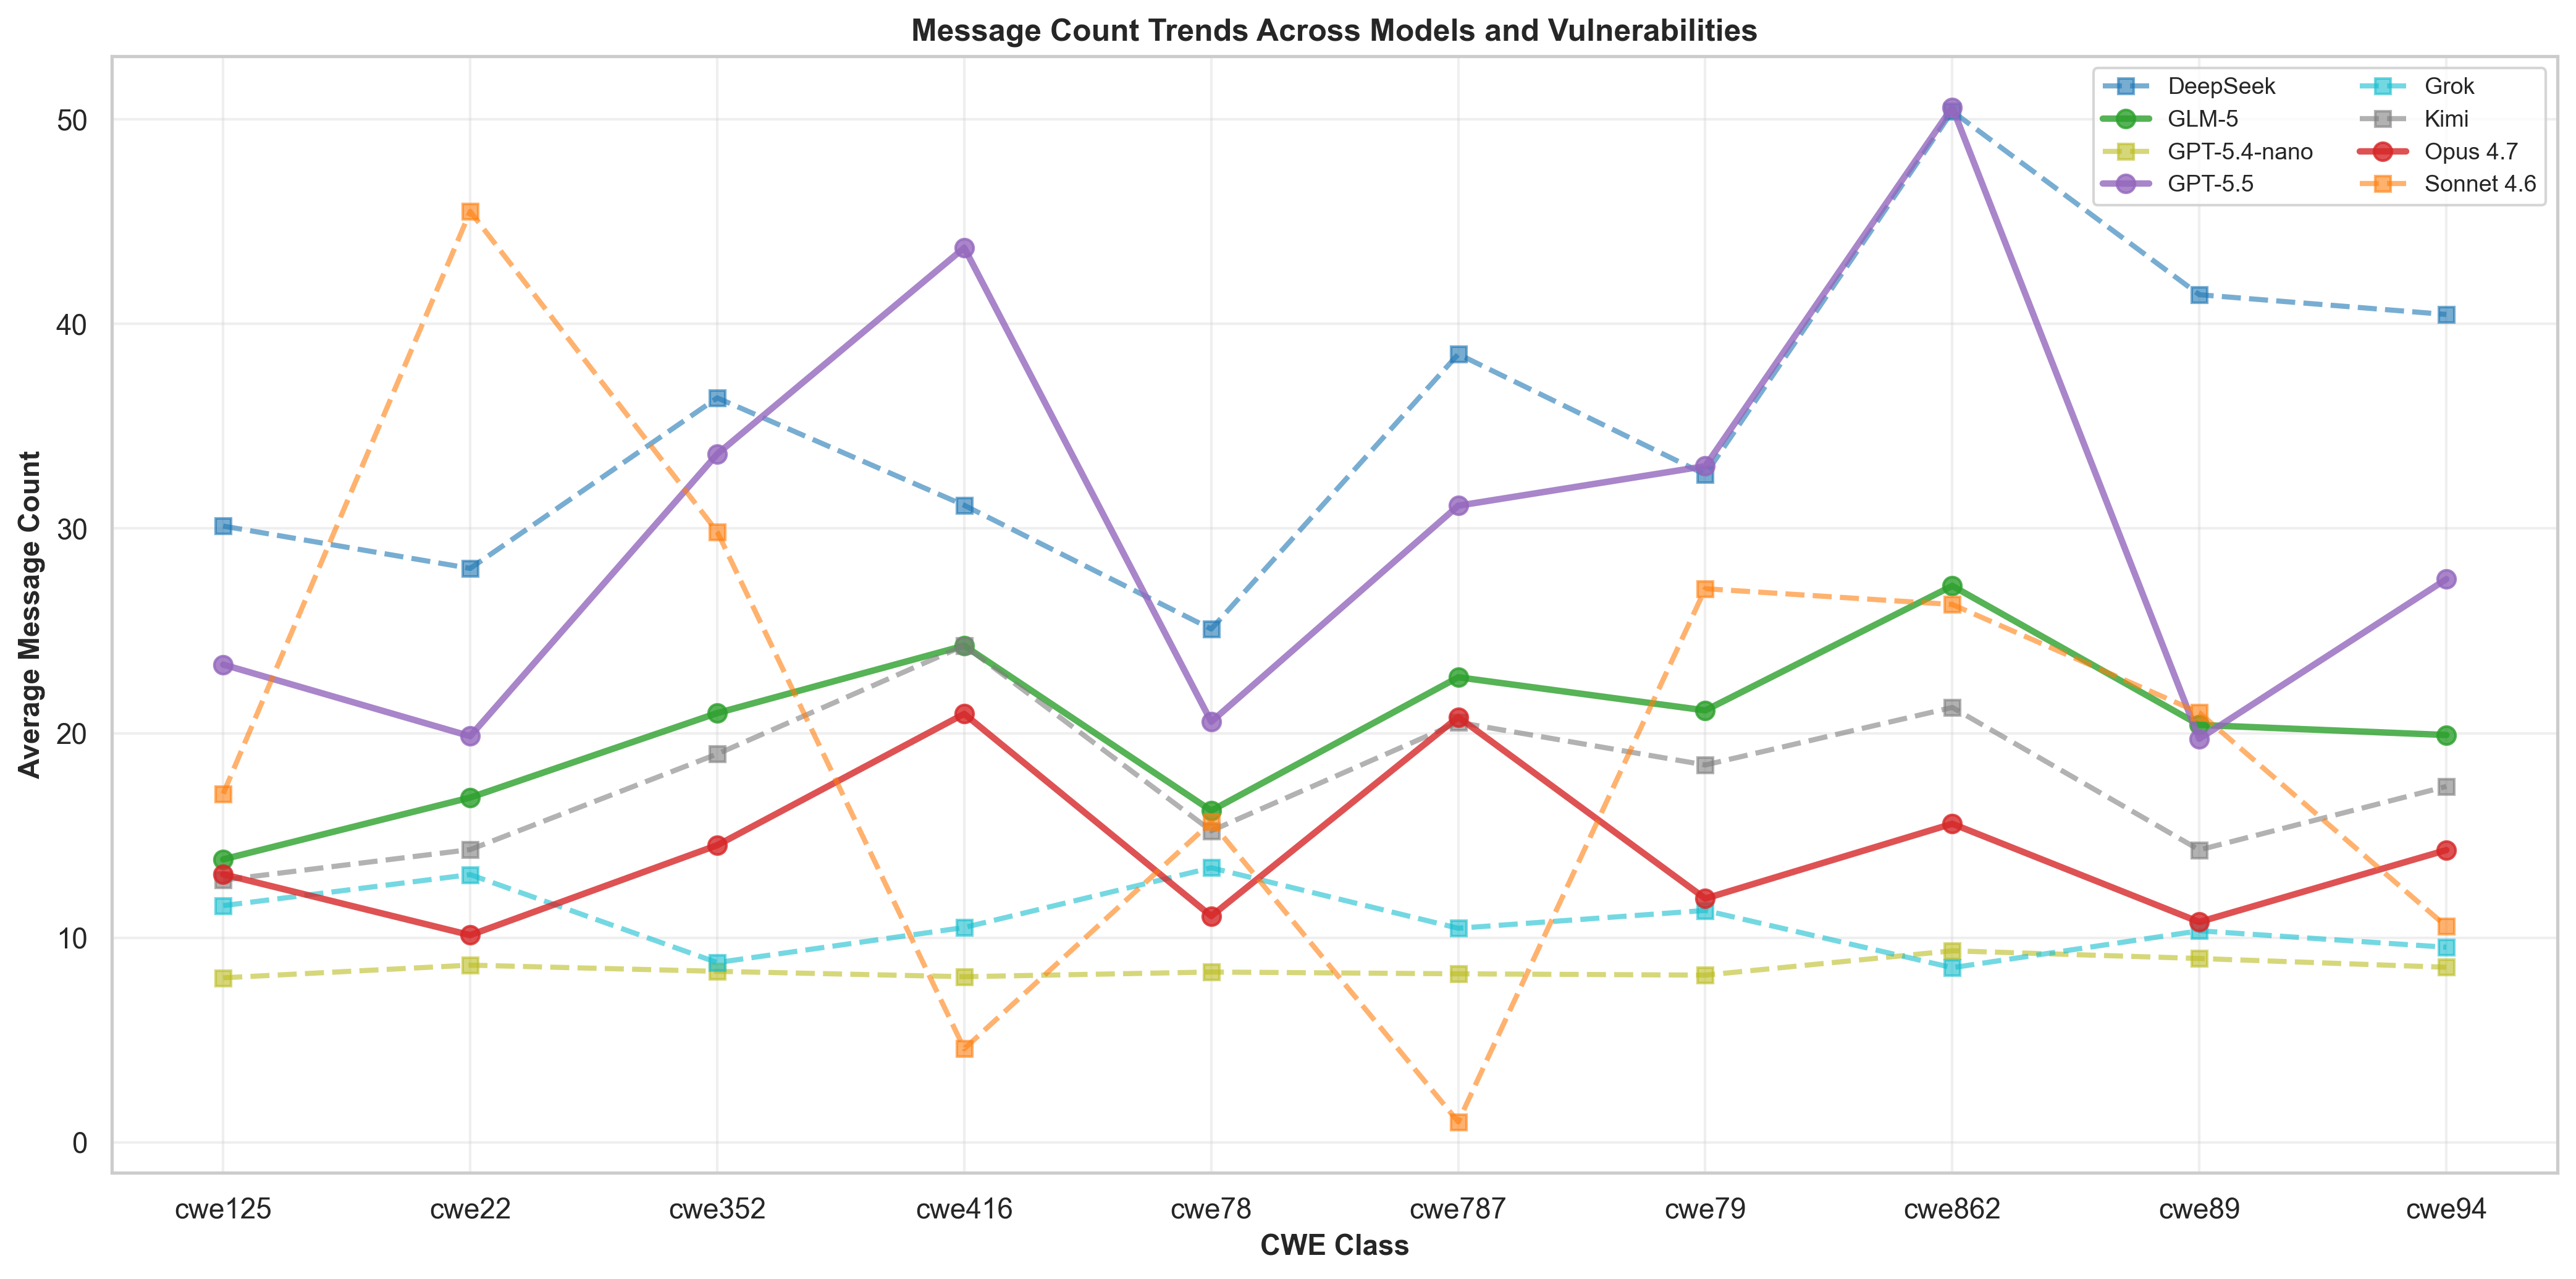

In [138]:
fig, ax = plt.subplots(figsize=(14, 7))

# Organize message counts by model and CWE
model_cwe_messages = defaultdict(lambda: defaultdict(list))
for model_name, prompts in data["raw_samples"].items():
    display_name = model_display_names.get(model_name, model_name)
    for prompt, cwes in prompts.items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                for sample in samples:
                    model_cwe_messages[display_name][cwe].append(sample["message_count"])

# Compute means per model and CWE
model_means = {}
for model in model_cwe_messages:
    model_means[model] = {}
    for cwe in model_cwe_messages[model]:
        model_means[model][cwe] = np.mean(model_cwe_messages[model][cwe])

# Sort CWEs
cwes_list = sorted(set(cwe for model_data in model_means.values() for cwe in model_data.keys()))
x_pos = np.arange(len(cwes_list))

# Colors for different model types
colors = {
    "Opus 4.7": "#D62728",
    "Sonnet 4.6": "#FF7F0E",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# Plot lines for each model
for model in sorted(model_means.keys()):
    if model not in colors:
        continue
    
    messages = [model_means[model].get(cwe, 0) for cwe in cwes_list]
    
    # Different line styles for frontier vs baseline
    if model in frontier_models:
        ax.plot(x_pos, messages, 'o-', linewidth=2.5, markersize=7,
                color=colors[model], alpha=0.8, label=model)
    else:
        ax.plot(x_pos, messages, 's--', linewidth=2, markersize=6,
                color=colors[model], alpha=0.6, label=model)

ax.set_xlabel("CWE Class", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Message Count", fontsize=11, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(cwes_list, rotation=0)
ax.set_title("Message Count Trends Across Models and Vulnerabilities", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("11_message_count_trends_by_model.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 11_message_count_trends_by_model.png")
plt.show()

## Plot 6: Message Count Trends Across Models by CWE (Multi-line Plot)

## Plot 5: Message Count vs Vulnerability Difficulty (Line Plot)

✓ Saved 12_message_count_trajectories.png


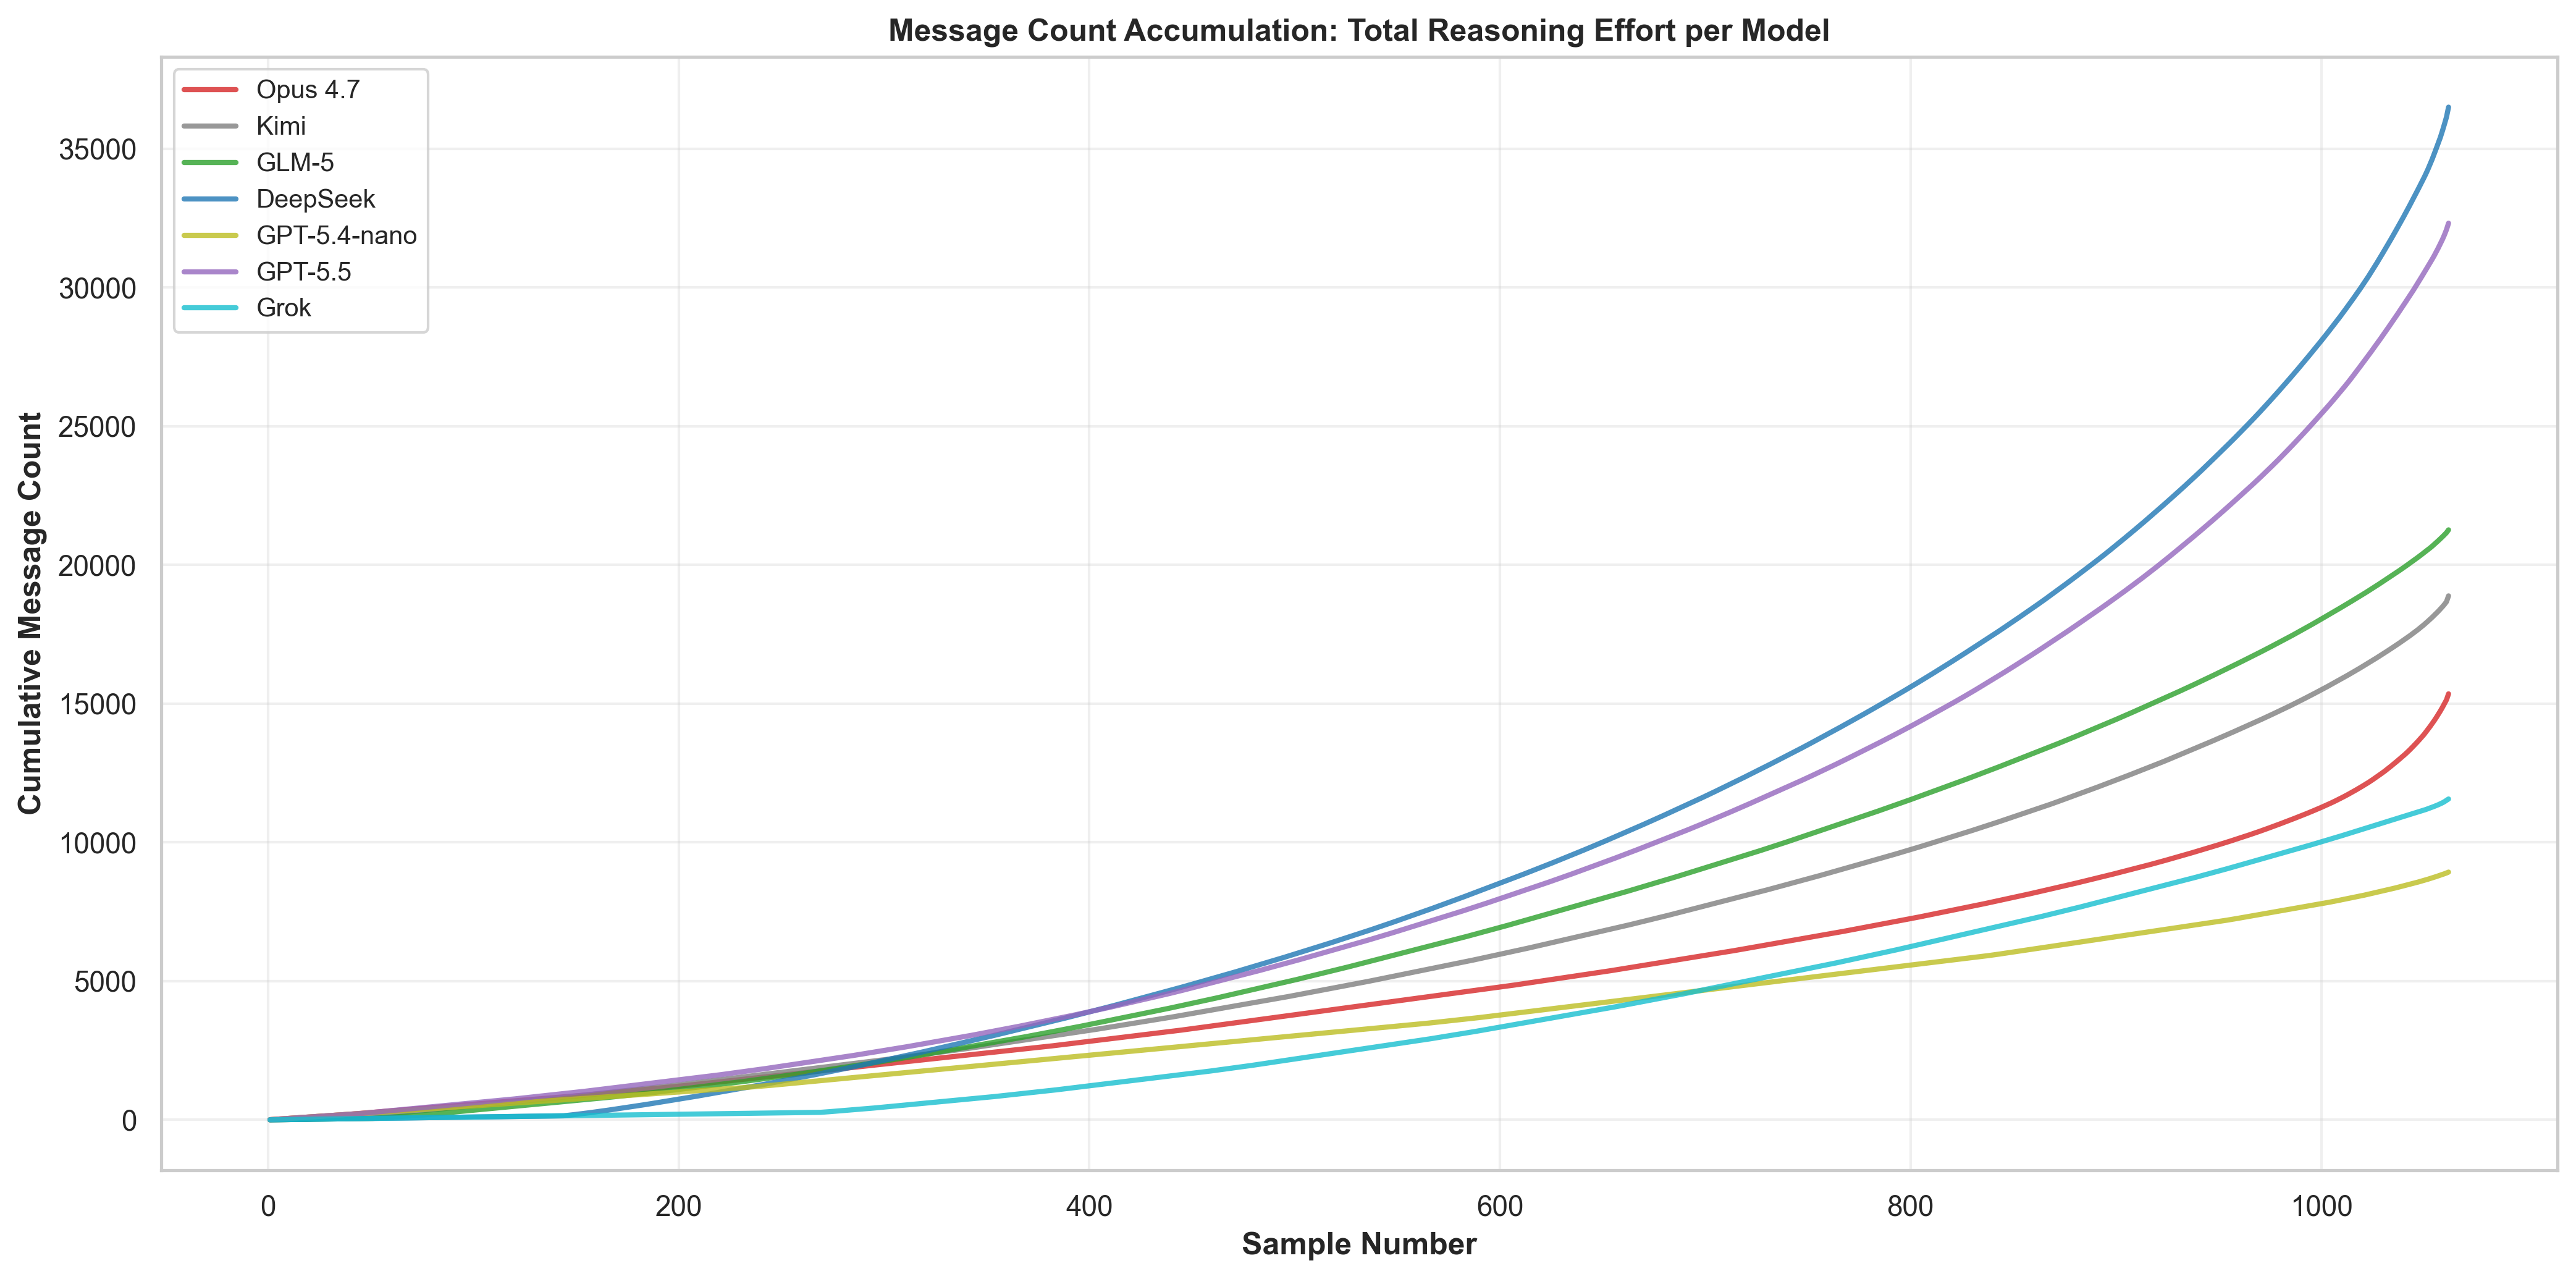

In [139]:
fig, ax = plt.subplots(figsize=(14, 7))

# Colors for models
model_colors = {
    "Opus 4.7": "#D62728",
    "GPT-5.5": "#9467BD",
    "GLM-5": "#2CA02C",
    "DeepSeek": "#1F77B4",
    "Grok": "#17BECF",
    "Kimi": "#7F7F7F",
    "GPT-5.4-nano": "#BCBD22",
}

# For each model, compute cumulative message count
for model_name in sorted(data["per_model"].keys()):
    display_name = model_display_names.get(model_name, model_name)
    if display_name in excluded_models or display_name == "Haiku":
        continue
    if display_name not in model_colors:
        continue
    
    # Collect all samples for this model
    model_samples = []
    for prompt, cwes in data["raw_samples"][model_name].items():
        if prompt != "plain":
            continue
        for cwe, framings in cwes.items():
            for framing, samples in framings.items():
                model_samples.extend(samples)
    
    # Sort by message count and compute cumulative sum
    message_counts = sorted([s["message_count"] for s in model_samples])
    cumulative_messages = np.cumsum(message_counts)
    sample_indices = np.arange(1, len(message_counts) + 1)
    
    # Plot cumulative trajectory
    ax.plot(sample_indices, cumulative_messages, linewidth=2, 
            color=model_colors[display_name], alpha=0.8, label=display_name)

ax.set_xlabel("Sample Number", fontsize=12, fontweight="bold")
ax.set_ylabel("Cumulative Message Count", fontsize=12, fontweight="bold")
ax.set_title("Message Count Accumulation: Total Reasoning Effort per Model", 
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.savefig("12_message_count_trajectories.png", dpi=300, bbox_inches="tight", facecolor="white")
print("✓ Saved 12_message_count_trajectories.png")
plt.show()